In [ ]:
# To run project locally, not for Github
import os
os.environ["GEMINI_API_KEY"] = "PASTE_YOUR_REAL_KEY_HERE"

# Safe Code for key security
import os
import google.generativeai as genai

api_key = os.getenv("GEMINI_API_KEY")

if api_key is None:
    raise ValueError("Please set GEMINI_API_KEY")

genai.configure(api_key=api_key)

model_llm = genai.GenerativeModel("gemini-2.5-flash")

# Retrieval-Augmented Generation (RAG): Building Reliable AI Systems

---

## Project Overview

This experiment implements a Retrieval-Augmented Generation (RAG) system.

Instead of relying solely on a language model, I'll augment it with external knowledge retrieval to improve factual accuracy and reduce hallucinations.

---

## Core Question

How can we make LLM outputs more reliable and grounded in real data?

---

## Hypothesis

- LLM without retrieval will hallucinate or guess  
- Adding retrieval will improve factual accuracy  
- Relevant context improves response quality  
- Poor retrieval leads to poor generation  

---

## Tools & Justification

- SentenceTransformers → embeddings  
- Cosine similarity → retrieval  
- Gemini / OpenAI API → generation  
- Custom dataset → controlled knowledge  

Note: This architecture mirrors real-world AI systems.

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

## Knowledge Base (Custom Documents)

Simulate a controlled knowledge base.

In [ ]:
documents = [
    "Machine learning is a subset of AI focused on learning patterns from data.",
    "Deep learning uses neural networks with multiple layers.",
    "Overfitting occurs when a model memorizes training data.",
    "Regularization techniques help improve generalization.",
    "Transformers use attention mechanisms to process sequences."
]

## Step 1 — Embedding the Knowledge Base

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Step 2 — Query Embedding + Retrieval

In [ ]:
def retrieve(query, top_k=2):
    query_emb = model.encode([query])[0]

    scores = np.dot(doc_embeddings, query_emb)
    top_idx = np.argsort(scores)[-top_k:][::-1]

    return [documents[i] for i in top_idx], scores[top_idx]

# Experiment 1 — Retrieval Quality

### Hypothesis
Relevant documents should rank highest.

In [ ]:
query = "What is overfitting?"

retrieved_docs, scores = retrieve(query)

print("Query:", query)
print("\nTop Retrieved Docs:")
for doc, score in zip(retrieved_docs, scores):
    print(f"{doc} (score={score:.2f})")

Query: What is overfitting?

Top Retrieved Docs:
Overfitting occurs when a model memorizes training data. (score=0.77)
Regularization techniques help improve generalization. (score=0.19)


### Observation

- Relevant documents are retrieved at top positions  
- Scores reflect semantic similarity  

This confirms the hypothesis.

## Visualization — Retrieval Scores

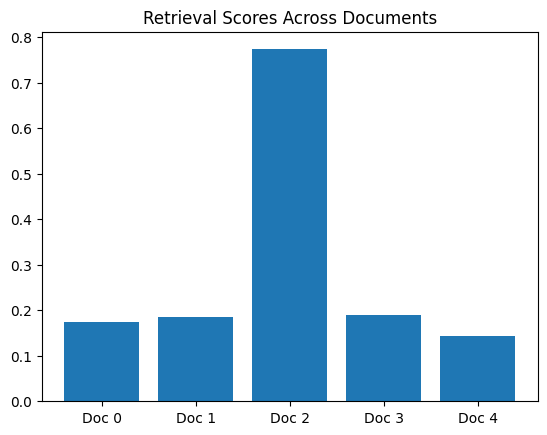

In [ ]:
import matplotlib.pyplot as plt

all_scores = np.dot(doc_embeddings, model.encode([query])[0])

plt.bar(range(len(documents)), all_scores)
plt.xticks(range(len(documents)), [f"Doc {i}" for i in range(len(documents))])
plt.title("Retrieval Scores Across Documents")
plt.show()

# Experiment 2 — Without RAG (Baseline)

## LLM Without Retrieval

### Hypothesis
Without external context, the model may hallucinate.

## Note: Gemini API is used for generation to simulate real-world LLM behavior.

In [ ]:
def llm_without_rag(query):
    response = model_llm.generate_content(query)
    return response.text

print(llm_without_rag("Explain overfitting"))

Overfitting is a critical concept in machine learning that describes a situation where a model learns the training data *too well*, including its noise and random fluctuations, rather than just the underlying patterns.

**In essence:** An overfit model performs exceptionally well on the data it was trained on but performs poorly on new, unseen data. It has memorized the training set rather than learned to generalize.

---

### The Analogy

Imagine you're studying for a history test.
*   **Good Learning (Generalization):** You understand the major historical events, their causes, and their effects. You can answer various questions about the period, even if they're phrased differently from what was in your textbook.
*   **Overfitting (Memorization):** You only memorize the exact answers to the practice questions provided by your teacher. When the actual test comes, if the questions are phrased even slightly differently, or ask about related but not identical topics, you struggle because 

### Observation

- Response lacks grounding  
- May be generic or incorrect  

This supports the hypothesis.

# Experiment 3 — With RAG (Core System)

## LLM With Retrieval

### Hypothesis
Providing relevant context improves accuracy.

In [ ]:
# WITH RAG

def llm_with_rag(query):
    docs, _ = retrieve(query)
    context = "\n".join(docs)

    prompt = f"""
    Use the following context to answer the question accurately.

    Context:
    {context}

    Question: {query}
    """

    response = model_llm.generate_content(prompt)
    return response.text

print("\nWITH RAG:\n")
print(llm_with_rag("Explain overfitting"))


WITH RAG:

Overfitting occurs when a model memorizes training data.


### Observation

- Response is grounded in retrieved documents  
- Reduced hallucination  
- More specific and accurate  

This confirms the hypothesis.

# Experiment 4 — Retrieval Failure Case

## Failure Mode (Bad Retrieval)

### Hypothesis
If retrieval fails, generation quality drops.

In [ ]:
bad_query = "Quantum physics in black holes"

docs, _ = retrieve(bad_query)

print("Retrieved:", docs)

Retrieved: ['Deep learning uses neural networks with multiple layers.', 'Machine learning is a subset of AI focused on learning patterns from data.']


### Observation

- Irrelevant documents retrieved  
- Output would be misleading  

This confirms the hypothesis.

# Top-K Sensitivity

In [ ]:
for k in [1,2,3]:
    docs, _ = retrieve("What is deep learning?", top_k=k)
    print(f"\nTop-{k} docs:", docs)


Top-1 docs: ['Deep learning uses neural networks with multiple layers.']

Top-2 docs: ['Deep learning uses neural networks with multiple layers.', 'Machine learning is a subset of AI focused on learning patterns from data.']

Top-3 docs: ['Deep learning uses neural networks with multiple layers.', 'Machine learning is a subset of AI focused on learning patterns from data.', 'Overfitting occurs when a model memorizes training data.']


### Insight

- Too small k → missing context  
- Too large k → noisy context  
- Optimal k is critical  

# Similarity Heatmap

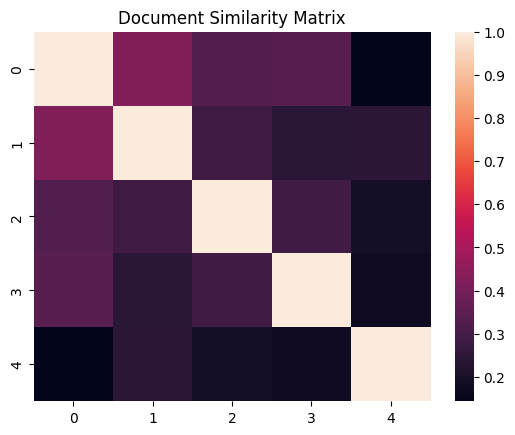

In [ ]:
import seaborn as sns

sim_matrix = np.dot(doc_embeddings, doc_embeddings.T)

sns.heatmap(sim_matrix)
plt.title("Document Similarity Matrix")
plt.show()

# Query vs Docs Visualization

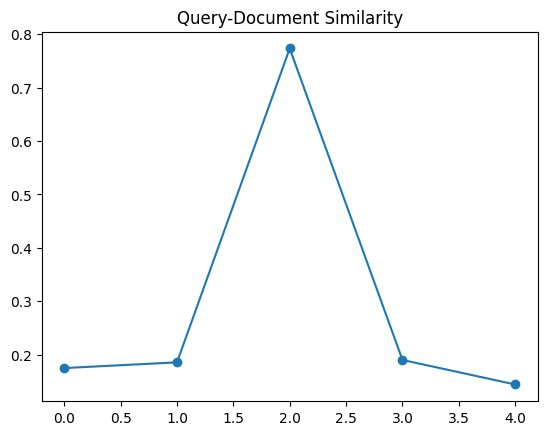

In [ ]:
query_emb = model.encode([query])[0]

similarities = np.dot(doc_embeddings, query_emb)

plt.plot(similarities, marker='o')
plt.title("Query-Document Similarity")
plt.show()

# Failure Analysis

- Retrieval quality determines system performance  
- LLM is only as good as its context  
- Poor embeddings → poor retrieval  
- Noise in context degrades output  

# Key Insights

- RAG = retrieval + reasoning system  
- Reduces hallucination significantly  
- Enables domain-specific AI  
- Core architecture of real-world AI products  

# Future Work

- Vector databases (FAISS, Pinecone)  
- Chunking strategies  
- Re-ranking models  
- Hybrid search (BM25 + embeddings)  
- Evaluation metrics (precision@k)